<a href="https://colab.research.google.com/github/zizizw/Business-Analytics-Projects/blob/main/Recommendation%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Recommendation System using Association Rules

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from datetime import datetime
from dateutil.relativedelta import relativedelta
coca_buyer_transactions = pd.read_csv('/kaggle/input/recommendationsystem/coca_data.csv')

In [ ]:
# Group by customer and get the brands in each customer
basket = coca_buyer_transactions.groupby(
    ['cust_id', 'prod_mfc_brand_cd']
)['sales_qty'].sum().unstack().reset_index().fillna(0).set_index('cust_id')

# Convert quantities to binary indicators (1 if brand was purchased, 0 otherwise)
def encode_units(x):
    return 1 if x > 0 else 0

basket_sets = basket.applymap(encode_units)

/tmp/ipykernel_31/3254739541.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)


In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Optimized parameters
MIN_SUPPORT = 0.03  # Lowered to capture more potential patterns
MIN_CONFIDENCE = 0.6  # Increased to ensure stronger rules
MIN_LIFT = 1.2  # Increased to find more meaningful associations

# Step 1: Mine frequent itemsets with optimized parameters
frequent_itemsets = fpgrowth(
    basket_sets,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3  # Limit antecedent combinations to 3 items for relevance
)

# Step 2: Generate all rules first
if not frequent_itemsets.empty:
    all_rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE,
        support_only=False
    )

    # Step 3: Filter for rules where COCA is the consequent
    if not all_rules.empty:
        coca_rules = all_rules[all_rules['consequents'].apply(lambda x: 'COCA' in x)]

        # Advanced filtering
        coca_rules = coca_rules[
            (coca_rules['lift'] > MIN_LIFT) &
            (coca_rules['conviction'] > 1) &  # Filters out coincidental patterns
            (coca_rules['antecedent support'] > 0.05)  # Rules must apply to >5% of transactions
        ].sort_values(
            by=['confidence', 'lift'],
            ascending=[False, False]
        )

        # Add useful metrics
        coca_rules['impact'] = coca_rules['support'] * coca_rules['lift']
    else:
        coca_rules = pd.DataFrame()  # Empty if no rules found
else:
    coca_rules = pd.DataFrame()  # Empty if no frequent itemsets

# Display optimized results
if not coca_rules.empty:
    print(coca_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'impact']].head())
else:
    print("No significant rules found with COCA as consequent. Try lowering min_support or min_confidence.")

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


       antecedents   consequents   support  confidence      lift    impact
95786       (STOU)  (COCA, NLSN)  0.069855    0.942029  1.506761  0.105255
35259       (DHIN)  (COCA, NLSN)  0.070661    0.929329  1.486447  0.105034
115306      (AUNT)  (COCA, NLSN)  0.062869    0.924901  1.479365  0.093007
36788       (CASC)  (COCA, NLSN)  0.052660    0.924528  1.478769  0.077872
116934      (YOPL)  (COCA, NLSN)  0.119291    0.923077  1.476447  0.176126


/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: divide by zero encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [ ]:
# Sort by confidence and lift
coca_rules_sorted = coca_rules.sort_values(['confidence', 'lift'], ascending=False)

# Display top rules
print(coca_rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

       antecedents   consequents   support  confidence      lift
95786       (STOU)  (COCA, NLSN)  0.069855    0.942029  1.506761
35259       (DHIN)  (COCA, NLSN)  0.070661    0.929329  1.486447
115306      (AUNT)  (COCA, NLSN)  0.062869    0.924901  1.479365
36788       (CASC)  (COCA, NLSN)  0.052660    0.924528  1.478769
116934      (YOPL)  (COCA, NLSN)  0.119291    0.923077  1.476447
31097       (BRYS)  (COCA, NLSN)  0.089199    0.922222  1.475080
32496       (ROHO)  (COCA, NLSN)  0.085975    0.922190  1.475029
108649      (BICK)  (COCA, NLSN)  0.124127    0.922156  1.474974
107358      (SMCK)  (COCA, NLSN)  0.112305    0.920705  1.472653
54901       (TWIZ)  (COCA, NLSN)  0.073885    0.919732  1.471098


In [ ]:
df = pd.read_csv('/kaggle/input/recommendationsystem/data_cleaned.csv')

In [ ]:
df['trans_dt'] = pd.to_datetime(df['trans_dt'], errors='coerce')
current_date = df['trans_dt'].max()
six_months_ago = current_date - relativedelta(months=6)

# 1. Customers with ≥5 purchases in last 6 months
active_customers = df[df['trans_dt'] >= six_months_ago].groupby('cust_id').filter(lambda x: len(x) >= 5)

# 2. Exclude customers who bought COCA or ACSE
coca_acse_buyers = df[
    (df['trans_dt'] >= six_months_ago) &
    (df['prod_mfc_brand_cd'].isin(['COCA', 'ACSE']))
]['cust_id'].unique()

target_customers = active_customers[~active_customers['cust_id'].isin(coca_acse_buyers)]
# Convert cust_id to list
target_customer_list = target_customers['cust_id'].tolist()

In [ ]:


# 1. Filter transactions for target customers
target_transactions = df[df['cust_id'].isin(target_customer_list)]

# 2. Group by cust_id to get purchased brands (unique)
customer_purchases = (
    target_transactions.groupby('cust_id')['prod_mfc_brand_cd']
    .apply(lambda x: set(x.unique()))  # Get unique brands per customer
    .reset_index()
)

# 3. Calculate probabilities + "buy together" brands
customer_results = []

for _, row in customer_purchases.iterrows():
    customer_id = row['cust_id']
    purchased_brands = row['prod_mfc_brand_cd']

    # Find matching rules (whether they bought COCA before or not)
    applicable_rules = coca_rules[
        coca_rules['antecedents'].apply(lambda x: x.issubset(purchased_brands))
    ]

    if not applicable_rules.empty:
        # Get the best rule (highest confidence)
        best_rule = applicable_rules.loc[applicable_rules['confidence'].idxmax()]

        customer_results.append({
            'cust_id': customer_id,
            'probability': best_rule['confidence'],
            'buy_together_brand': ', '.join(best_rule['antecedents'])  # e.g., "PEPSI, DASANI"
        })
    else:
        customer_results.append({
            'cust_id': customer_id,
            'probability': 0,  # No rule applies
            'buy_together_brand': 'no_rule_match'
        })

# Convert to DataFrame
result_df = pd.DataFrame(customer_results).sort_values('probability', ascending=False)

print(result_df.head())

          cust_id  probability buy_together_brand
74     1040216208     0.942029               STOU
79     1045764278     0.942029               STOU
1368  33250030936     0.942029               STOU
1180  33237968854     0.942029               STOU
401    1124975349     0.942029               STOU


In [ ]:
result_df.to_csv('/kaggle/working/association_rules_results1.csv', index=False)

## Evaluation

Rule Quality Summary:
           support   confidence         lift   conviction
count  1682.000000  1682.000000  1682.000000  1682.000000
mean      0.085876     0.706573     1.704462     2.111306
std       0.053129     0.085365     0.195212     0.566667
min       0.030360     0.600000     1.257776     1.427992
25%       0.048092     0.637944     1.580704     1.760220
50%       0.069586     0.685255     1.701084     1.915094
75%       0.105521     0.757095     1.825212     2.238600
max       0.410263     0.942029     2.507590     6.465274


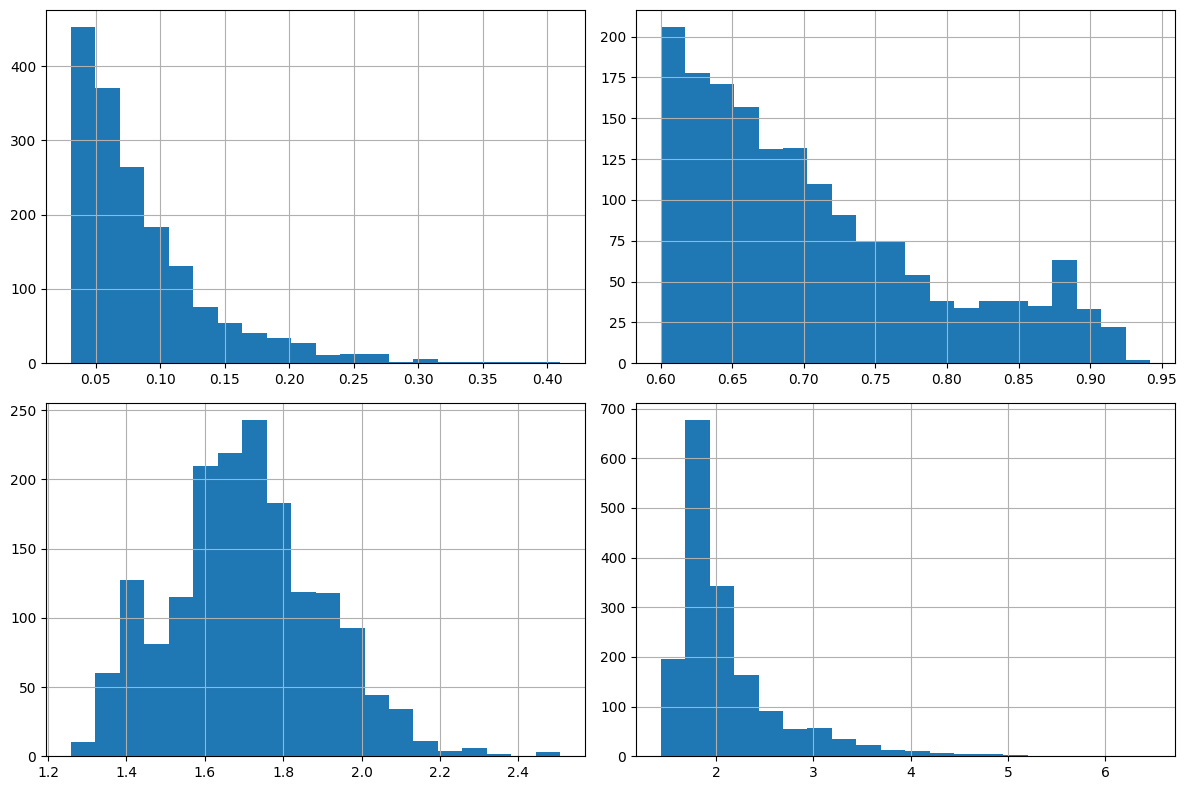

In [ ]:
if not coca_rules.empty:
    print("Rule Quality Summary:")
    print(coca_rules[['support', 'confidence', 'lift', 'conviction']].describe())

    # Visualize key metrics
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    coca_rules['support'].hist(ax=axes[0,0], bins=20)
    coca_rules['confidence'].hist(ax=axes[0,1], bins=20)
    coca_rules['lift'].hist(ax=axes[1,0], bins=20)
    coca_rules['conviction'].hist(ax=axes[1,1], bins=20)
    plt.tight_layout()
    plt.show()

In [ ]:
# Assuming you'll target top N customers
top_customers = result_df[result_df['probability'] > 0].sort_values('probability', ascending=False)

print("\nPotential Campaign Impact:")
print(f"Total targetable customers: {len(top_customers)}")
print(f"Average purchase probability: {top_customers['probability'].mean():.2%}")
print(f"Top 3 recommended brand combinations:")
print(top_customers['buy_together_brand'].value_counts().head(3))


Potential Campaign Impact:
Total targetable customers: 1590
Average purchase probability: 89.74%
Top 3 recommended brand combinations:
buy_together_brand
YOPL    57
STOU    44
GENM    35
Name: count, dtype: int64


In [ ]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

# Then run your FP-Growth and rule generation on the training set
# (Repeat the same code you have but using train instead of coca_buyer_transactions)

# Evaluation on test set
def evaluate_recommendations(rules, test_data):
    # Convert test data to the same basket format
    test_basket = test_data.groupby(
        ['cust_id', 'prod_mfc_brand_cd']
    )['sales_qty'].sum().unstack().reset_index().fillna(0).set_index('cust_id')
    test_basket_sets = test_basket.applymap(encode_units)

    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0
    total_recommended = 0
    total_actual = test_basket_sets['COCA'].sum()

    for cust_id, row in test_basket_sets.iterrows():
        purchased_brands = set(row[row == 1].index) - {'COCA'}
        bought_coca = row['COCA'] == 1

        # Find applicable rules
        applicable_rules = rules[
            rules['antecedents'].apply(lambda x: x.issubset(purchased_brands))
        ]

        if not applicable_rules.empty:
            # We would recommend COCA to this customer
            total_recommended += 1
            if bought_coca:
                true_positives += 1
            else:
                false_positives += 1
        else:
            # We would NOT recommend COCA to this customer
            if bought_coca:
                false_negatives += 1
            else:
                true_negatives += 1

    precision = true_positives / total_recommended if total_recommended > 0 else 0
    recall = true_positives / total_actual if total_actual > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (true_positives + true_negatives) / len(test_basket_sets)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'true_negatives': true_negatives,
        'false_negatives': false_negatives,
        'total_recommended': total_recommended,
        'total_actual': total_actual,
        'total_customers': len(test_basket_sets)
    }

evaluation_results = evaluate_recommendations(coca_rules, test)
print("Evaluation Metrics:", evaluation_results)

/tmp/ipykernel_31/704542441.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_basket_sets = test_basket.applymap(encode_units)


Evaluation Metrics: {'accuracy': 0.341555137706006, 'precision': 0.04190167351902253, 'recall': 0.8547129695251595, 'f1_score': 0.07988694826558326, 'true_positives': 3618, 'false_positives': 82727, 'true_negatives': 39614, 'false_negatives': 615, 'total_recommended': 86345, 'total_actual': 4233, 'total_customers': 126574}


# prod level

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
from dateutil.relativedelta import relativedelta

# 1. Prepare product-level transaction data
product_basket = coca_buyer_transactions.groupby(
    ['cust_id', 'prod_id']
)['sales_qty'].sum().unstack().reset_index().fillna(0).set_index('cust_id')

# Binary encoding function
def encode_units(x):
    return 1 if x > 0 else 0

product_basket_sets = product_basket.applymap(encode_units)

# 2. Identify all COCA product IDs
coca_product_ids = coca_buyer_transactions[
    coca_buyer_transactions['prod_mfc_brand_cd'] == 'COCA'
]['prod_id'].unique()

# 3. Mine frequent itemsets and generate rules
MIN_SUPPORT = 0.02  # Might need lower support for product-level
MIN_CONFIDENCE = 0.5
MIN_LIFT = 1.1

frequent_itemsets = fpgrowth(
    product_basket_sets,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3
)

# Generate all rules first
if not frequent_itemsets.empty:
    all_rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE
    )

    # Filter for rules where consequent is any COCA product
    coca_product_rules = all_rules[
        all_rules['consequents'].apply(
            lambda x: any(prod_id in x for prod_id in coca_product_ids)
        )
    ]

    # Additional filtering
    coca_product_rules = coca_product_rules[
        (coca_product_rules['lift'] > MIN_LIFT) &
        (coca_product_rules['antecedent support'] > 0.03)
    ].sort_values(
        by=['confidence', 'lift'],
        ascending=[False, False]
    )

    # Add product info to make rules more interpretable
    product_info = coca_buyer_transactions[['prod_id', 'prod_desc', 'prod_mfc_brand_cd']].drop_duplicates()

    def get_product_details(prod_ids):
        details = []
        for prod_id in prod_ids:
            info = product_info[product_info['prod_id'] == prod_id]
            if not info.empty:
                details.append(f"{prod_id} ({info['prod_desc'].values[0]})")
        return ", ".join(details)

    coca_product_rules['antecedent_details'] = coca_product_rules['antecedents'].apply(get_product_details)
    coca_product_rules['consequent_details'] = coca_product_rules['consequents'].apply(get_product_details)
else:
    coca_product_rules = pd.DataFrame()

# 4. Target specific customers with product recommendations
df['trans_dt'] = pd.to_datetime(df['trans_dt'], errors='coerce')
current_date = df['trans_dt'].max()
six_months_ago = current_date - relativedelta(months=6)

active_customers = df[df['trans_dt'] >= six_months_ago].groupby('cust_id').filter(lambda x: len(x) >= 5)
coca_acse_buyers = df[
    (df['trans_dt'] >= six_months_ago) &
    (df['prod_mfc_brand_cd'].isin(['COCA', 'ACSE']))
]['cust_id'].unique()

target_customers = active_customers[~active_customers['cust_id'].isin(coca_acse_buyers)]
target_customer_list = target_customers['cust_id'].tolist()

# Get product purchase history for target customers
target_transactions = df[df['cust_id'].isin(target_customer_list)]
customer_product_purchases = (
    target_transactions.groupby('cust_id')['prod_id']
    .apply(lambda x: set(x.unique()))
    .reset_index()
)

# Generate personalized recommendations
product_recommendations = []

for _, row in customer_product_purchases.iterrows():
    customer_id = row['cust_id']
    purchased_products = row['prod_id']

    # Find matching rules
    applicable_rules = coca_product_rules[
        coca_product_rules['antecedents'].apply(lambda x: x.issubset(purchased_products))
    ]

    if not applicable_rules.empty:
        # Get the best rule (highest confidence)
        best_rule = applicable_rules.loc[applicable_rules['confidence'].idxmax()]

        # Get specific COCA product recommendations
        recommended_products = []
        for product_id in best_rule['consequents']:
            product_name = product_info[product_info['prod_id'] == product_id]['prod_desc'].values[0]
            recommended_products.append(f"{product_id} ({product_name})")

        product_recommendations.append({
            'cust_id': customer_id,
            'probability': best_rule['confidence'],
            'buy_together_products': best_rule['antecedent_details'],
            'recommended_coca_products': ", ".join(recommended_products),
            'lift': best_rule['lift'],
            'support': best_rule['support']
        })
    else:
        product_recommendations.append({
            'cust_id': customer_id,
            'probability': 0,
            'buy_together_products': 'no_rule_match',
            'recommended_coca_products': 'none',
            'lift': 0,
            'support': 0
        })

# Convert to DataFrame
product_recommendation_df = pd.DataFrame(product_recommendations).sort_values('probability', ascending=False)

# 5. Evaluation (requires sklearn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import ndcg_score

# Split data for evaluation
train, test = train_test_split(coca_buyer_transactions, test_size=0.2, random_state=42)

def evaluate_product_recommendations(rules, test_data):
    # Convert test data to product basket format
    test_basket = test_data.groupby(
        ['cust_id', 'prod_id']
    )['sales_qty'].sum().unstack().reset_index().fillna(0).set_index('cust_id')
    test_basket_sets = test_basket.applymap(encode_units)

    # Get all COCA product IDs in test set
    test_coca_products = set(test_data[
        test_data['prod_mfc_brand_cd'] == 'COCA'
    ]['prod_id'].unique())

    true_positives = 0
    false_positives = 0
    total_recommended = 0
    total_actual = test_basket_sets[list(test_coca_products)].sum(axis=1).astype(bool).sum()

    for cust_id, row in test_basket_sets.iterrows():
        purchased_products = set(row[row == 1].index) - test_coca_products

        # Find applicable rules
        applicable_rules = rules[
            rules['antecedents'].apply(lambda x: x.issubset(purchased_products))
        ]

        if not applicable_rules.empty:
            # We would recommend COCA products to this customer
            total_recommended += 1
            if any(row[list(applicable_rules.iloc[0]['consequents'])] == 1):
                true_positives += 1
            else:
                false_positives += 1

    precision = true_positives / total_recommended if total_recommended > 0 else 0
    recall = true_positives / total_actual if total_actual > 0 else 0

    return {
        'precision': precision,
        'recall': recall,
        'f1_score': 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0,
        'coverage': len(test_basket_sets) / len(test_data['cust_id'].unique()),
        'true_positives': true_positives,
        'false_positives': false_positives,
        'total_actual_coca_buyers': total_actual
    }

# Evaluation on test set
product_evaluation = evaluate_product_recommendations(coca_product_rules, test)
print("Product-Level Evaluation Metrics:", product_evaluation)

/tmp/ipykernel_31/2567294630.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  product_basket_sets = product_basket.applymap(encode_units)
/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/tmp/ipykernel_31/2567294630.py:150: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_basket_sets = test_basket.applymap(encode_units)


Product-Level Evaluation Metrics: {'precision': 0.23958333333333334, 'recall': 0.015764222069910898, 'f1_score': 0.029581993569131836, 'coverage': 1.0, 'true_positives': 23, 'false_positives': 73, 'total_actual_coca_buyers': 1459}


In [ ]:
product_recommendation_df.to_csv('/kaggle/working/association_rules_product_level_result.csv', index=False)